![image info](https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/images/banner_1.png)

# Proyecto 1 - Predicción de popularidad en canción

En este proyecto podrán poner en práctica sus conocimientos sobre modelos predictivos basados en árboles y ensambles, y sobre la disponibilización de modelos. Para su desarrollo tengan en cuenta las instrucciones dadas en la "Guía del proyecto 1: Predicción de popularidad en canción".

**Entrega**: La entrega del proyecto deberán realizarla durante la semana 4. Sin embargo, es importante que avancen en la semana 3 en el modelado del problema y en parte del informe, tal y como se les indicó en la guía.

Para hacer la entrega, deberán adjuntar el informe autocontenido en PDF a la actividad de entrega del proyecto que encontrarán en la semana 4, y subir el archivo de predicciones a la competencia de Kaggle cuyo link estará disponible en la sección del Coursera del proyecto.

## Datos para la predicción de popularidad en cancion

En este proyecto se usará el conjunto de datos de datos de popularidad en canciones, donde cada observación representa una canción y se tienen variables como: duración de la canción, acusticidad y tempo, entre otras. El objetivo es predecir qué tan popular es la canción. Para más detalles puede visitar el siguiente enlace: [datos](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset).

## Ejemplo predicción conjunto de test para envío a Kaggle

En esta sección encontrarán el formato en el que deben guardar los resultados de la predicción para que puedan subirlos a la competencia en Kaggle.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

In [3]:
# Carga de datos de archivo .csv
dataTraining = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTrain_Spotify.csv')
dataTesting = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTest_Spotify.csv', index_col=0)

In [4]:
# Visualización datos de entrenamiento
dataTraining.head()

,Unnamed: 0,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity
0,0,7hUhmkALyQ8SX9mJs5XI3D,Love and Rockets,Love and Rockets,Motorcycle,211533,False,0.305,0.8490,9,...,1,0.0549,0.000058,0.056700,0.4640,0.3200,141.793,4,goth,22
1,1,5x59U89ZnjZXuNAAlc8X1u,Filippa Giordano,Filippa Giordano,"Addio del passato - From ""La traviata""",196000,False,0.287,0.1900,7,...,0,0.0370,0.930000,0.000356,0.0834,0.1330,83.685,4,opera,22
2,2,70Vng5jLzoJLmeLu3ayBQq,Susumu Yokota,Symbol,Purple Rose Minuet,216506,False,0.583,0.5090,1,...,1,0.0362,0.777000,0.202000,0.1150,0.5440,90.459,3,idm,37
3,3,1cRfzLJapgtwJ61xszs37b,Franz Liszt;YUNDI,Relajación y siestas,"Liebeslied (Widmung), S. 566",218346,False,0.163,0.0368,8,...,1,0.0472,0.991000,0.899000,0.1070,0.0387,69.442,3,classical,0
4,4,47d5lYjbiMy0EdMRV8lRou,Scooter,Scooter Forever,The Darkside,173160,False,0.647,0.9210,2,...,1,0.1850,0.000939,0.371000,0.1310,0.1710,137.981,4,techno,27


count    79800.000000
mean        33.265301
std         22.330871
min          0.000000
25%         17.000000
50%         35.000000
75%         50.000000
max        100.000000
Name: popularity, dtype: float64

Mín: 0, Máx: 100


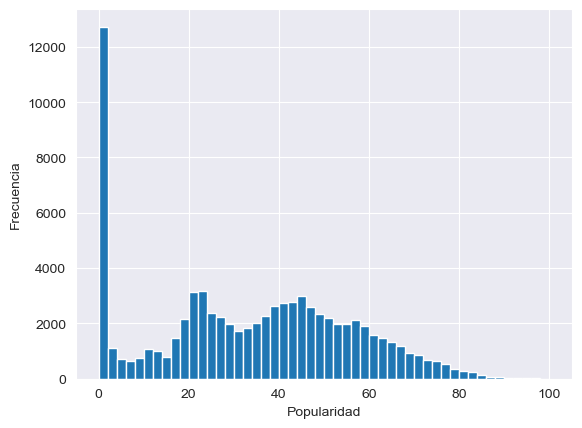

In [5]:
print(dataTraining['popularity'].describe())
print(f"\nMín: {dataTraining['popularity'].min()}, Máx: {dataTraining['popularity'].max()}")

plt.hist(dataTraining['popularity'], bins=50)
plt.xlabel('Popularidad')
plt.ylabel('Frecuencia')
plt.show()

In [6]:
# ¿Cuántas canciones tienen popularidad 0?
zero_pop = (dataTraining['popularity'] == 0).sum()
print(f"Canciones con popularidad 0: {zero_pop} ({zero_pop/len(dataTraining)*100:.1f}%)")

# Mira algunas canciones con popularidad 0
print("\nEjemplos de popularidad 0:")
print(dataTraining[dataTraining['popularity'] == 0][['artists', 'track_name', 'track_genre']].head(10))

# Compara con canciones populares
print("\nEjemplos de popularidad alta:")
print(dataTraining[dataTraining['popularity'] > 80][['artists', 'track_name', 'popularity']].head(10))

Canciones con popularidad 0: 11230 (14.1%)

Ejemplos de popularidad 0:
                                          artists  \
3                               Franz Liszt;YUNDI   
11                        Burna Boy;Blxst;Kehlani   
38   Daddy Yankee;Natti Natasha;Becky G;Bad Bunny   
40                                    James Brown   
60                                   Randall King   
75                                         Juanes   
104                                      La Renga   
107                                 Bishop Briggs   
114                 Wisin & Yandel;Anthony Santos   
128                             Dusty Springfield   

                            track_name track_genre  
3         Liebeslied (Widmung), S. 566   classical  
11                               Solid       dance  
38                        Dura - Remix     hip-hop  
40         Merry Christmas, I Love You        funk  
60                 You in a Honky Tonk     country  
75                     Herm

In [ ]:
# Visualización datos de test
dataTesting.head()

In [ ]:
# Predicción del conjunto de test - acá se genera un número aleatorio como ejemplo
np.random.seed(42)
y_pred = pd.DataFrame(np.random.rand(dataTesting.shape[0]) * 100, index=dataTesting.index, columns=['Popularity'])

In [ ]:
# Guardar predicciones en formato exigido en la competencia de kaggle
y_pred.to_csv('test_submission_file.csv', index_label='ID')
y_pred.head()

In [ ]:
# from sklearn.model_selection import train_test_split

# # Separar características y variable objetivo
# y_train = dataTraining['popularity']
# X_train = dataTraining.drop(columns='popularity', inplace = False)
# X_test = dataTesting


In [ ]:
# from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score
# from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
# from sklearn.tree import DecisionTreeClassifier

# modelo_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
# ensemble_dt = BaggingClassifier(estimator = modelo_dt, n_estimators = 100, random_state=42)

# ensemble_dt.fit(X_train, y_train)

# y_pred_dt = ensemble_dt.predict(X_test)
# y_pred_dt = pd.DataFrame(y_pred_dt, index = X_test.index, columns=['Popularity'])
# y_pred_dt.to_csv('test_submission_file_dt.csv', index_label='ID')